# Laboratorio 5: Clasificación de tweets sobre desastres

## Objetivo

El objetivo de este laboratorio es aplicar técnicas de minería de texto para analizar y clasificar tweets. Se busca construir y comparar modelos que determinen si un tweet se refiere a un desastre real, así como estudiar el sentimiento de los mensajes y evaluar si la negatividad aporta información a la clasificación.

La variable objetivo es `target`:

- `0`: el tweet no se refiere a un desastre real.
- `1`: el tweet se refiere a un desastre real.

El análisis incluye la descripción y limpieza de los datos, unigramas, bigramas y trigramas, nubes de palabras, comparación de modelos, análisis de sentimiento con VADER, evaluación de la variable de negatividad y una función para clasificar tweets nuevos.


In [1]:
import html
import re
import warnings

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

RANDOM_STATE = 42
COLORES = {0: "#4C78A8", 1: "#E45756"}
ETIQUETAS = {0: "No desastre", 1: "Desastre real"}

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 150)
warnings.filterwarnings("ignore", category=FutureWarning)

nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)
stop_words = set(stopwords.words("english"))
stop_words_modelo = (stop_words - {"no", "not", "nor"}) | {"amp"}

print("Librerías y recursos cargados correctamente.")

Librerías y recursos cargados correctamente.


In [2]:
ruta_datos = "data/train.csv"
columnas_requeridas = ["id", "keyword", "location", "text", "target"]
datos_originales = pd.read_csv(ruta_datos)

faltantes_columnas = [c for c in columnas_requeridas if c not in datos_originales.columns]
if faltantes_columnas:
    raise ValueError(f"Faltan columnas requeridas: {faltantes_columnas}")

print("Dimensiones:", datos_originales.shape)
print("Columnas:", datos_originales.columns.tolist())
display(datos_originales.head())

resumen_calidad = pd.DataFrame({
    "tipo": datos_originales.dtypes.astype(str),
    "valores faltantes": datos_originales.isna().sum(),
    "porcentaje faltante": (datos_originales.isna().mean() * 100).round(2),
    "valores únicos": datos_originales.nunique(),
})
display(resumen_calidad)
print("Filas duplicadas completas:", datos_originales.duplicated().sum())
print("Textos duplicados:", datos_originales["text"].duplicated().sum())
print("Identificadores duplicados:", datos_originales["id"].duplicated().sum())

Dimensiones: (7613, 5)
Columnas: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


,tipo,valores faltantes,porcentaje faltante,valores únicos
id,int64,0,0.00,7613
keyword,object,61,0.80,221
location,object,2533,33.27,3341
text,object,0,0.00,7503
target,int64,0,0.00,2


Filas duplicadas completas: 0
Textos duplicados: 110
Identificadores duplicados: 0


In [3]:
textos_repetidos = datos_originales[
    datos_originales.duplicated(subset="text", keep=False)
].sort_values("text")

etiquetas_por_texto = datos_originales.groupby("text")["target"].nunique()
textos_contradictorios = etiquetas_por_texto[etiquetas_por_texto > 1].index
filas_contradictorias = datos_originales[
    datos_originales["text"].isin(textos_contradictorios)
].sort_values(["text", "target"])

print("Filas involucradas en textos repetidos:", len(textos_repetidos))
print("Textos distintos que se repiten:", textos_repetidos["text"].nunique())
print("Textos con etiquetas contradictorias:", len(textos_contradictorios))
print("Filas involucradas en contradicciones:", len(filas_contradictorias))
display(filas_contradictorias[columnas_requeridas].head(20))

Filas involucradas en textos repetidos: 179
Textos distintos que se repiten: 69
Textos con etiquetas contradictorias: 18
Filas involucradas en contradicciones: 55


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,0
2830,4068,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,1
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,1
2833,4077,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,1


## Descripción y calidad de los datos

El conjunto de datos contiene 7,613 registros y cinco variables. La columna `id` identifica cada tweet; `keyword` contiene una palabra clave asociada; `location` representa la ubicación declarada; `text` contiene el contenido del tweet; y `target` indica si el tweet se relaciona con un desastre real.

La variable `text`, que será la fuente principal de información para el modelo preliminar, no presenta valores faltantes. La columna `keyword` contiene 61 valores faltantes, equivalentes al 0.80 % de los registros, mientras que `location` contiene 2,533 valores faltantes, equivalentes al 33.27 %. Debido a que el modelo de clasificación utilizará principalmente el texto, estos valores faltantes no requieren imputación en este análisis. Tampoco se eliminarán filas debido a valores faltantes en `keyword` o `location`.

No se encontraron filas completas duplicadas ni identificadores repetidos. Sin embargo, se encontraron 110 repeticiones en la columna `text`. Esto significa que algunos tweets tienen el mismo contenido, pero poseen identificadores distintos o diferencias en otras variables.

Antes de eliminar estos registros es necesario determinar si los textos repetidos tienen la misma clasificación. Si un mismo texto aparece tanto con `target = 0` como con `target = 1`, existe una inconsistencia en las etiquetas. Además, permitir que textos idénticos aparezcan simultáneamente en entrenamiento y prueba podría causar fuga de información y producir métricas demasiado optimistas.

In [4]:
datos_sin_duplicados_originales = datos_originales[
    ~datos_originales["text"].isin(textos_contradictorios)
].copy()
datos_sin_duplicados_originales = (
    datos_sin_duplicados_originales
    .drop_duplicates(subset="text", keep="first")
    .reset_index(drop=True)
)

filas_eliminadas_originales = len(datos_originales) - len(datos_sin_duplicados_originales)
print("Dimensiones originales:", datos_originales.shape)
print("Dimensiones después de tratar textos originales repetidos:", datos_sin_duplicados_originales.shape)
print("Filas eliminadas:", filas_eliminadas_originales)

Dimensiones originales: (7613, 5)
Dimensiones después de tratar textos originales repetidos: (7485, 5)
Filas eliminadas: 128


### Tratamiento de textos repetidos

Se encontraron 179 filas involucradas en repeticiones, correspondientes a 69 textos distintos. Dentro de estos casos, 18 textos presentaban etiquetas contradictorias: el mismo contenido estaba clasificado en algunos registros como desastre real y en otros como no desastre. Estas contradicciones involucraban 55 filas.

Se decidió eliminar todas las apariciones de los textos con etiquetas contradictorias, debido a que no existe una forma objetiva de determinar cuál de las etiquetas es correcta utilizando únicamente la información disponible.

Para los textos repetidos con etiquetas consistentes se conservó una sola aparición. Esta decisión evita que los mismos tweets incrementen artificialmente las frecuencias de palabras y reduce el riesgo de que textos idénticos aparezcan simultáneamente en los conjuntos de entrenamiento y prueba.

Después del tratamiento, el conjunto de datos contiene 7,485 registros, sin textos exactamente repetidos ni textos con etiquetas contradictorias.

,target,cantidad,porcentaje,categoría
0,0,4297,57.41,No desastre
1,1,3188,42.59,Desastre real


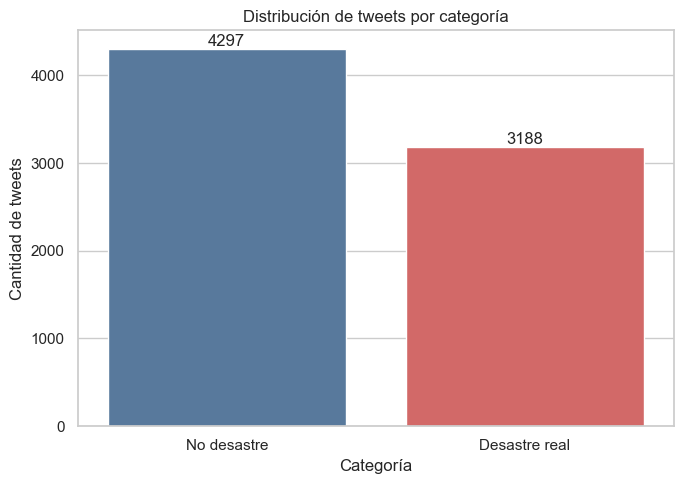

In [5]:
resumen_target = (
    datos_sin_duplicados_originales["target"].value_counts().sort_index()
    .rename_axis("target").reset_index(name="cantidad")
)
resumen_target["porcentaje"] = (
    resumen_target["cantidad"] / len(datos_sin_duplicados_originales) * 100
).round(2)
resumen_target["categoría"] = resumen_target["target"].map(ETIQUETAS)
display(resumen_target)

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=datos_sin_duplicados_originales,
    x="target",
    hue="target",
    palette=COLORES,
    legend=False,
)
ax.set_title("Distribución de tweets por categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de tweets")
ax.set_xticks([0, 1], ["No desastre", "Desastre real"])
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.show()

### Distribución de la variable objetivo

Después del tratamiento de textos repetidos y contradictorios, el conjunto de datos contiene 7,485 tweets. De ellos, 4,297, equivalentes al 57.41 %, no corresponden a desastres reales. Los 3,188 registros restantes, equivalentes al 42.59 %, sí están relacionados con desastres reales.

La categoría de tweets que no representan desastres es la más frecuente. Sin embargo, la diferencia entre ambas categorías no constituye un desbalance extremo. Para mantener esta proporción en los conjuntos utilizados por el modelo, posteriormente se realizará una división estratificada entre entrenamiento y prueba.

Además del accuracy, se utilizarán precision, recall y F1-score para evaluar el modelo, debido a que estas métricas permiten analizar su comportamiento en cada categoría.

,tweets,media_caracteres,mediana_caracteres,media_palabras,mediana_palabras
target,,,,,
No desastre,4297,95.58,101.0,14.67,15.0
Desastre real,3188,108.02,114.0,15.14,15.0


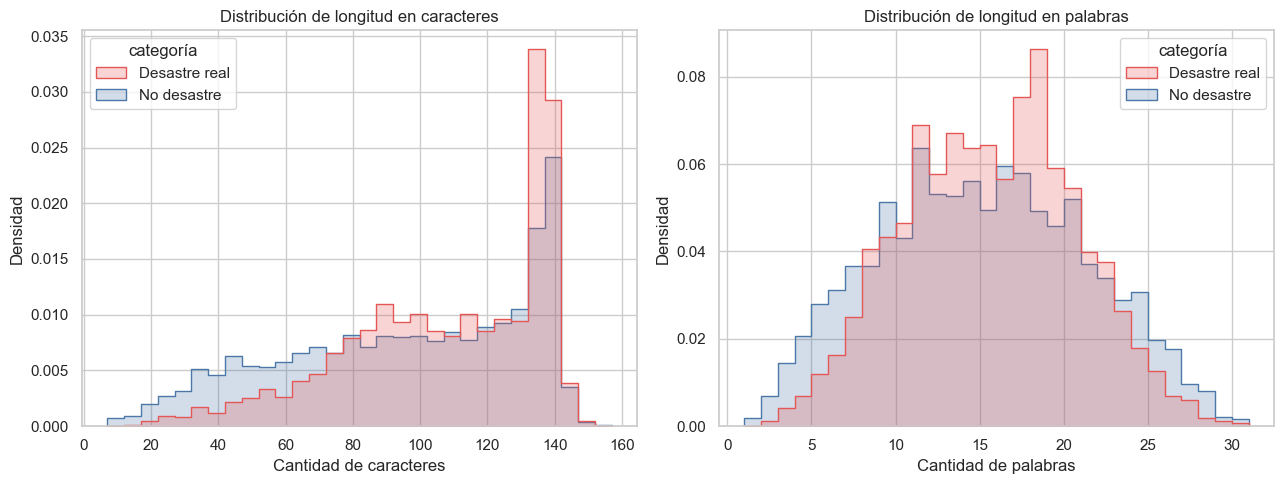

In [6]:
datos_sin_duplicados_originales["cantidad_caracteres"] = datos_sin_duplicados_originales["text"].str.len()
datos_sin_duplicados_originales["cantidad_palabras"] = datos_sin_duplicados_originales["text"].str.split().str.len()

resumen_longitud = (
    datos_sin_duplicados_originales.groupby("target")
    .agg(
        tweets=("text", "count"),
        media_caracteres=("cantidad_caracteres", "mean"),
        mediana_caracteres=("cantidad_caracteres", "median"),
        media_palabras=("cantidad_palabras", "mean"),
        mediana_palabras=("cantidad_palabras", "median"),
    ).round(2)
)
resumen_longitud.index = resumen_longitud.index.map(ETIQUETAS)
display(resumen_longitud)

datos_grafica_longitud = datos_sin_duplicados_originales.assign(
    categoría=datos_sin_duplicados_originales["target"].map(ETIQUETAS)
)
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(
    data=datos_grafica_longitud, x="cantidad_caracteres", hue="categoría",
    bins=30, element="step", stat="density", common_norm=False,
    palette={"No desastre": COLORES[0], "Desastre real": COLORES[1]}, ax=ejes[0],
)
ejes[0].set_title("Distribución de longitud en caracteres")
ejes[0].set_xlabel("Cantidad de caracteres")
ejes[0].set_ylabel("Densidad")
sns.histplot(
    data=datos_grafica_longitud, x="cantidad_palabras", hue="categoría",
    bins=30, element="step", stat="density", common_norm=False,
    palette={"No desastre": COLORES[0], "Desastre real": COLORES[1]}, ax=ejes[1],
)
ejes[1].set_title("Distribución de longitud en palabras")
ejes[1].set_xlabel("Cantidad de palabras")
ejes[1].set_ylabel("Densidad")
plt.tight_layout()
plt.show()

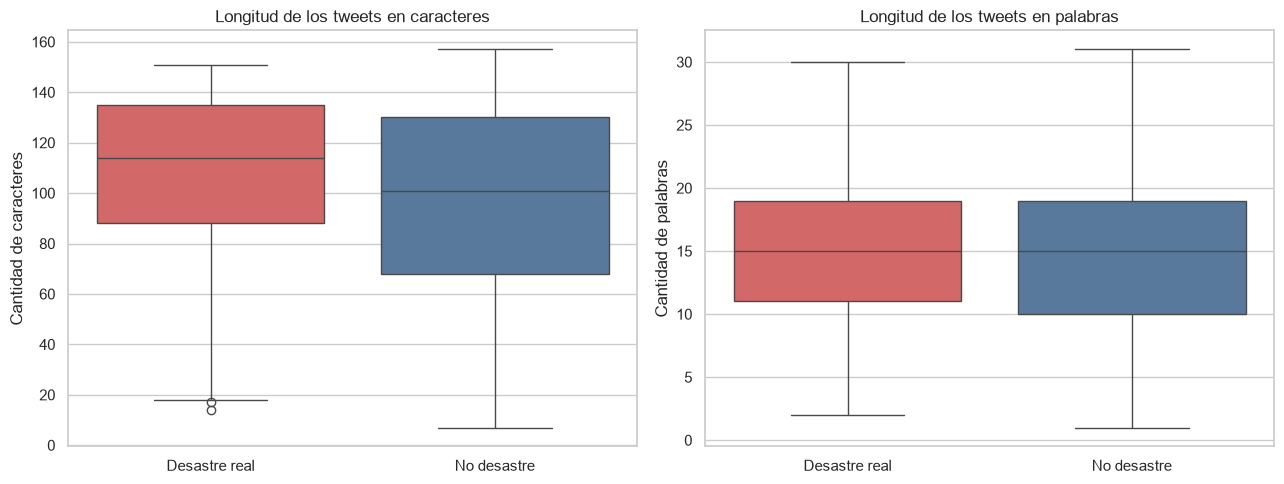

In [7]:
datos_grafica_longitud = datos_sin_duplicados_originales.assign(
    categoría=datos_sin_duplicados_originales["target"].map(ETIQUETAS)
)

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=datos_grafica_longitud,
    x="categoría",
    y="cantidad_caracteres",
    hue="categoría",
    palette={"No desastre": COLORES[0], "Desastre real": COLORES[1]},
    legend=False,
    ax=ejes[0],
)
ejes[0].set_title("Longitud de los tweets en caracteres")
ejes[0].set_xlabel("")
ejes[0].set_ylabel("Cantidad de caracteres")

sns.boxplot(
    data=datos_grafica_longitud,
    x="categoría",
    y="cantidad_palabras",
    hue="categoría",
    palette={"No desastre": COLORES[0], "Desastre real": COLORES[1]},
    legend=False,
    ax=ejes[1],
)
ejes[1].set_title("Longitud de los tweets en palabras")
ejes[1].set_xlabel("")
ejes[1].set_ylabel("Cantidad de palabras")

plt.tight_layout()
plt.show()


### Longitud de los tweets

Los tweets relacionados con desastres reales presentan una longitud media de 108.02 caracteres y una mediana de 114 caracteres. En cambio, los tweets que no corresponden a desastres tienen una media de 95.58 caracteres y una mediana de 101 caracteres. Por lo tanto, los tweets sobre desastres tienden a ser más extensos en cantidad de caracteres.

La diferencia en cantidad de palabras es menor. Los tweets sobre desastres contienen en promedio 15.14 palabras, mientras que los tweets que no representan desastres contienen 14.67. Ambas categorías presentan una mediana de 15 palabras.

Los histogramas muestran un solapamiento considerable entre las categorías, especialmente en la cantidad de palabras. Esto indica que la longitud por sí sola no permitiría clasificar correctamente los tweets. Sin embargo, la mayor cantidad de caracteres observada en los tweets sobre desastres puede considerarse una característica potencialmente informativa.

La diferencia entre caracteres y palabras también puede deberse a la presencia de palabras más largas, hashtags, enlaces y detalles específicos en los tweets relacionados con desastres.

## Limpieza y preprocesamiento del texto

Los tweets contienen elementos que pueden generar ruido, como URLs, menciones, signos de puntuación, caracteres especiales y palabras de uso muy frecuente. Por esta razón, se creó una función de preprocesamiento que normaliza los textos antes de calcular frecuencias y entrenar el modelo.

Las actividades realizadas fueron:

1. Conversión del texto a minúsculas.
2. Conversión de entidades HTML, por ejemplo `&amp;`.
3. Eliminación de URLs.
4. Eliminación de menciones de usuarios.
5. Eliminación del símbolo `#`, conservando la palabra del hashtag.
6. Eliminación de apóstrofes, puntuación, emoticonos y caracteres especiales.
7. Eliminación de stopwords en inglés.
8. Conservación de las negaciones `no`, `not` y `nor`.
9. Normalización de espacios.
10. Conservación de números, debido a que cantidades, fechas o expresiones como `911` podrían aportar información sobre emergencias.

No se aplicó stemming ni lematización en esta etapa, con el propósito de conservar palabras interpretables para el análisis de frecuencias y las nubes de palabras.

In [8]:
def clean_text(texto):
    # Normaliza un tweet para los modelos de clasificación de desastres.
    texto = html.unescape(str(texto))
    texto = texto.lower()
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", "")
    texto = texto.replace("’", "'")
    texto = texto.replace("'", "")
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = [token for token in texto.split() if token not in stop_words_modelo]
    return " ".join(tokens)

ejemplos_limpieza = [
    "@News The road is NOT safe! Call 911. #earthquake https://t.co/example",
    "Fire &amp; smoke reported near the building!",
    "I am not worried about this at all :)"
]
for ejemplo in ejemplos_limpieza:
    print("Original:", ejemplo)
    print("Limpio:  ", clean_text(ejemplo))
    print("-" * 80)

Original: @News The road is NOT safe! Call 911. #earthquake https://t.co/example
Limpio:   road not safe call 911 earthquake
--------------------------------------------------------------------------------
Original: Fire &amp; smoke reported near the building!
Limpio:   fire smoke reported near building
--------------------------------------------------------------------------------
Original: I am not worried about this at all :)
Limpio:   not worried
--------------------------------------------------------------------------------


In [9]:
datos_sin_duplicados_originales["clean_text"] = datos_sin_duplicados_originales["text"].apply(clean_text)

textos_limpios_con_etiquetas = datos_sin_duplicados_originales.groupby("clean_text")["target"].nunique()
textos_limpios_contradictorios = textos_limpios_con_etiquetas[
    textos_limpios_con_etiquetas > 1
].index

datos_texto = datos_sin_duplicados_originales[
    ~datos_sin_duplicados_originales["clean_text"].isin(textos_limpios_contradictorios)
].copy()
datos_texto = datos_texto[datos_texto["clean_text"].str.strip().ne("")]
datos_texto = datos_texto.drop_duplicates(subset="clean_text", keep="first").reset_index(drop=True)

filas_eliminadas_limpieza = len(datos_sin_duplicados_originales) - len(datos_texto)
porcentaje_eliminado_limpieza = filas_eliminadas_limpieza / len(datos_sin_duplicados_originales) * 100

print("Registros antes del tratamiento posterior:", len(datos_sin_duplicados_originales))
print("Registros finales:", len(datos_texto))
print("Filas eliminadas:", filas_eliminadas_limpieza)
print(f"Porcentaje eliminado: {porcentaje_eliminado_limpieza:.2f}%")
print("Textos limpios vacíos restantes:", datos_texto["clean_text"].str.strip().eq("").sum())
print("Textos limpios repetidos restantes:", datos_texto["clean_text"].duplicated().sum())
print("Contradicciones restantes:", (datos_texto.groupby("clean_text")["target"].nunique() > 1).sum())

Registros antes del tratamiento posterior: 7485
Registros finales: 6737
Filas eliminadas: 748
Porcentaje eliminado: 9.99%
Textos limpios vacíos restantes: 0
Textos limpios repetidos restantes: 0
Contradicciones restantes: 0


In [10]:
comparacion_limpieza = datos_sin_duplicados_originales[
    ["text", "clean_text", "target"]
].sample(10, random_state=RANDOM_STATE)

display(comparacion_limpieza)


,text,clean_text,target
2826,BLOG: Rain much needed as drought conditions worsen: Right now Charlotte and much of the surrounding area haveÛ_ http://t.co/OLzaVTJFKH,blog rain much needed drought conditions worsen right charlotte much surrounding area,1
6956,Ancient Mayan Tablet with Hieroglyphics Honors Lowly King http://t.co/Im6m4XAeN2,ancient mayan tablet hieroglyphics honors lowly king,0
3014,There has not been 1 real tear out of #Shelli 's eyes this entire episode. #bb17,not 1 real tear shelli eyes entire episode bb17,0
6569,Ebay Snipe RT? http://t.co/SlQnph34Nt Lego Power Miners Set 8960 Thunder Driller Boxed. ?Please Favorite &amp; Share,ebay snipe rt lego power miners set 8960 thunder driller boxed please favorite share,0
4606,#Flashflood causes #landslide in Gilgit #Pakistan Damage to 20 homes farmland roads and bridges #365disasters http://t.co/911F3IXRH0,flashflood causes landslide gilgit pakistan damage 20 homes farmland roads bridges 365disasters,1
4355,@pmarca content is held hostage by network due to affiliation fees.,content held hostage network due affiliation fees,1
6813,The worst voice I can ever hear is the 'Nikki your in trouble' voice from my mom,worst voice ever hear nikki trouble voice mom,0
468,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO,illegal alien released obama dhs 4 times charged rape murder santa maria ca woman prior offenses,1
3127,#EMERGENCY in Odai Bucharest Romania 600 Dogs Dying!They are so Hungry that they EAT EACH OTHER! http://t.co/pjigXPVPl0,emergency odai bucharest romania 600 dogs dying hungry eat,1
1295,RT @HuffPostComedy: We should build a wall that keeps Burning Man attendees from coming home http://t.co/xwVW1sft4I http://t.co/j7HUKhWmal,rt build wall keeps burning man attendees coming home,0


In [11]:
textos_limpios_vacios = datos_sin_duplicados_originales["clean_text"].str.strip().eq("").sum()
filas_limpias_repetidas = datos_sin_duplicados_originales[
    datos_sin_duplicados_originales.duplicated(subset="clean_text", keep=False)
].sort_values("clean_text")
textos_limpios_con_etiquetas = datos_sin_duplicados_originales.groupby("clean_text")["target"].nunique()
textos_limpios_contradictorios = textos_limpios_con_etiquetas[
    textos_limpios_con_etiquetas > 1
].index
filas_limpias_contradictorias = datos_sin_duplicados_originales[
    datos_sin_duplicados_originales["clean_text"].isin(textos_limpios_contradictorios)
].sort_values(["clean_text", "target"])

print("Textos vacíos después de limpiar:", textos_limpios_vacios)
print("Repeticiones posteriores a la primera:", datos_sin_duplicados_originales["clean_text"].duplicated().sum())
print("Filas involucradas en repeticiones limpias:", len(filas_limpias_repetidas))
print("Textos limpios distintos que se repiten:", filas_limpias_repetidas["clean_text"].nunique())
print("Textos limpios con etiquetas contradictorias:", len(textos_limpios_contradictorios))
print("Filas involucradas en contradicciones:", len(filas_limpias_contradictorias))

display(
    filas_limpias_repetidas[["text", "clean_text", "target"]].head(20)
)
display(
    filas_limpias_contradictorias[["text", "clean_text", "target"]].head(30)
)


Textos vacíos después de limpiar: 0
Repeticiones posteriores a la primera: 680
Filas involucradas en repeticiones limpias: 974
Textos limpios distintos que se repiten: 294
Textos limpios con etiquetas contradictorias: 68
Filas involucradas en contradicciones: 251


,text,clean_text,target
4239,0-day bug in fully patched OS X comes under active exploit to bypass password ... - Ars Technica http://t.co/F7OgzrNPfv,0 day bug fully patched os x comes active exploit bypass password ars technica,0
4252,0-day bug in fully patched OS X comes under active exploit to bypass password ... - Ars Technica http://t.co/53P4oOO1XN,0 day bug fully patched os x comes active exploit bypass password ars technica,0
3849,100 1' MIX NEW FLAT DOUBLE SIDED LINERLESS BOTTLE CAPS YOU CHOOSE MIX FLATTENED - Full reÛ_ http://t.co/wRNpywyaLj http://t.co/Qv7IYdoVx9,100 1 mix new flat double sided linerless bottle caps choose mix flattened full,0
3846,100 1' MIX NEW FLAT DOUBLE SIDED LINERLESS BOTTLE CAPS YOU CHOOSE MIX FLATTENED - Full reÛ_ http://t.co/w00kjPrfdR http://t.co/mIXl1pFRJe,100 1 mix new flat double sided linerless bottle caps choose mix flattened full,0
3862,12' 72W CREE LED Work Light Bar Alloy Spot Flood Combo Diving Offroad 4WD Boat - Full readÛ_ http://t.co/XWN7rgVkzC http://t.co/SWPDQ84boI,12 72w cree led work light bar alloy spot flood combo diving offroad 4wd boat full read,0
3884,12' 72W CREE LED Work Light Bar Alloy Spot Flood Combo Diving Offroad 4WD Boat - Full readÛ_ http://t.co/MJMwA72ER6 http://t.co/ADx9iYi246,12 72w cree led work light bar alloy spot flood combo diving offroad 4wd boat full read,0
4901,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/N1tjCt8HMC http://t.co/pYTQM7rVP0,13 reasons love women military lulgzimbestpicts,0
4904,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/IAPvTqxLht http://t.co/WAMKRe6CKD,13 reasons love women military lulgzimbestpicts,0
4905,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/uZ1yiZ7n6m http://t.co/IjwAr15H16,13 reasons love women military lulgzimbestpicts,0
4895,13 reasons why we love women in the military - lulgzimbestpicts http://t.co/XKMLQ99SjY http://t.co/a3RGQuCUgo,13 reasons love women military lulgzimbestpicts,0


,text,clean_text,target
3856,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/VDeFmulx43 http://t.co/yqpAIjSa5g,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,0
3869,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/O1SMUh2unn http://t.co/xqj6WgiuQH,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,0
3872,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/1QT51r5h98 http://t.co/OQH1JbUEnl,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,0
3863,2pcs 18W CREE Led Work Light Offroad Lamp Car Truck Boat Mining 4WD FLOOD BEAM - Full reaÛ_ http://t.co/ApWXS5Mm44 http://t.co/DS76loZLSu,2pcs 18w cree led work light offroad lamp car truck boat mining 4wd flood beam full rea,1
5712,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/eaTFro3d5x,360wisenews chinas stock market crash gems rubble,0
5732,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/gQskwqZuUl,360wisenews chinas stock market crash gems rubble,0
5718,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/9Naw3QOQOL,360wisenews chinas stock market crash gems rubble,1
5728,#360WiseNews : China's Stock Market Crash: Are There Gems In The Rubble? http://t.co/aOd2ftBMGU,360wisenews chinas stock market crash gems rubble,1
2788,Angry Woman Openly Accuses NEMA Of Stealing Relief Materials Meant For IDPs: An angry Internally Displaced wom... http://t.co/Khd99oZ7u3,angry woman openly accuses nema stealing relief materials meant idps angry internally displaced wom,0
2805,Angry Woman Openly Accuses NEMA Of Stealing Relief Materials Meant For IDPs: An angry Internally Displaced wom... http://t.co/6ySbCSSzYS,angry woman openly accuses nema stealing relief materials meant idps angry internally displaced wom,0


### Validación posterior al preprocesamiento

Después de aplicar la función de limpieza no se encontraron textos vacíos. Sin embargo, se detectaron 680 repeticiones adicionales en `clean_text`. Al considerar también la primera aparición, 974 filas estaban involucradas en repeticiones y correspondían a 294 textos limpios distintos.

Estas repeticiones aparecieron porque algunos tweets originales se diferenciaban únicamente por URLs, menciones, puntuación u otros elementos eliminados durante el preprocesamiento. También se identificaron 68 textos limpios con etiquetas contradictorias, los cuales involucraban 251 filas.

Se eliminaron todas las apariciones de los textos limpios con etiquetas contradictorias, ya que no era posible determinar objetivamente cuál etiqueta era correcta. Para los textos limpios repetidos con etiquetas consistentes se conservó una sola aparición.

El conjunto de datos textual definitivo contiene 6,737 registros, sin textos vacíos, repeticiones exactas ni etiquetas contradictorias. En esta etapa se eliminaron 748 filas, equivalentes al 9.99 % de los 7,485 registros disponibles antes del tratamiento posterior.

La decisión reduce la fuga de información y evita que textos equivalentes inflen las frecuencias. No obstante, eliminar casi el 10 % de los registros también puede causar pérdida de información y modificar la distribución del corpus. Por ello, este procedimiento debe considerarse una limitación del análisis.


## Análisis de n-gramas

Un n-grama es una secuencia de `n` términos consecutivos. Los unigramas representan palabras individuales, mientras que los bigramas representan pares de palabras consecutivas.

El análisis se realizará por separado para los tweets que representan desastres reales y para los que no representan desastres. Para cada término se calculará:

- **Frecuencia:** cantidad total de apariciones del término.
- **Probabilidad relativa:** frecuencia del término dividida entre la cantidad total de apariciones de todos los términos de la categoría.

Este análisis permitirá identificar palabras y expresiones asociadas con cada clase y estudiar si los bigramas proporcionan más contexto que las palabras individuales.

,ngrama,frecuencia,probabilidad (%)
0,like,245,0.718180
1,im,237,0.694729
2,not,200,0.586270
3,get,162,0.474878
4,no,146,0.427977
5,dont,141,0.413320
6,new,131,0.384007
7,one,129,0.378144
8,body,102,0.298997
9,would,96,0.281409


,ngrama,frecuencia,probabilidad (%)
0,fire,164,0.613658
1,news,111,0.415341
2,no,102,0.381665
3,police,96,0.359214
4,via,92,0.344247
5,people,90,0.336763
6,like,89,0.333022
7,not,89,0.333022
8,disaster,87,0.325538
9,california,85,0.318054


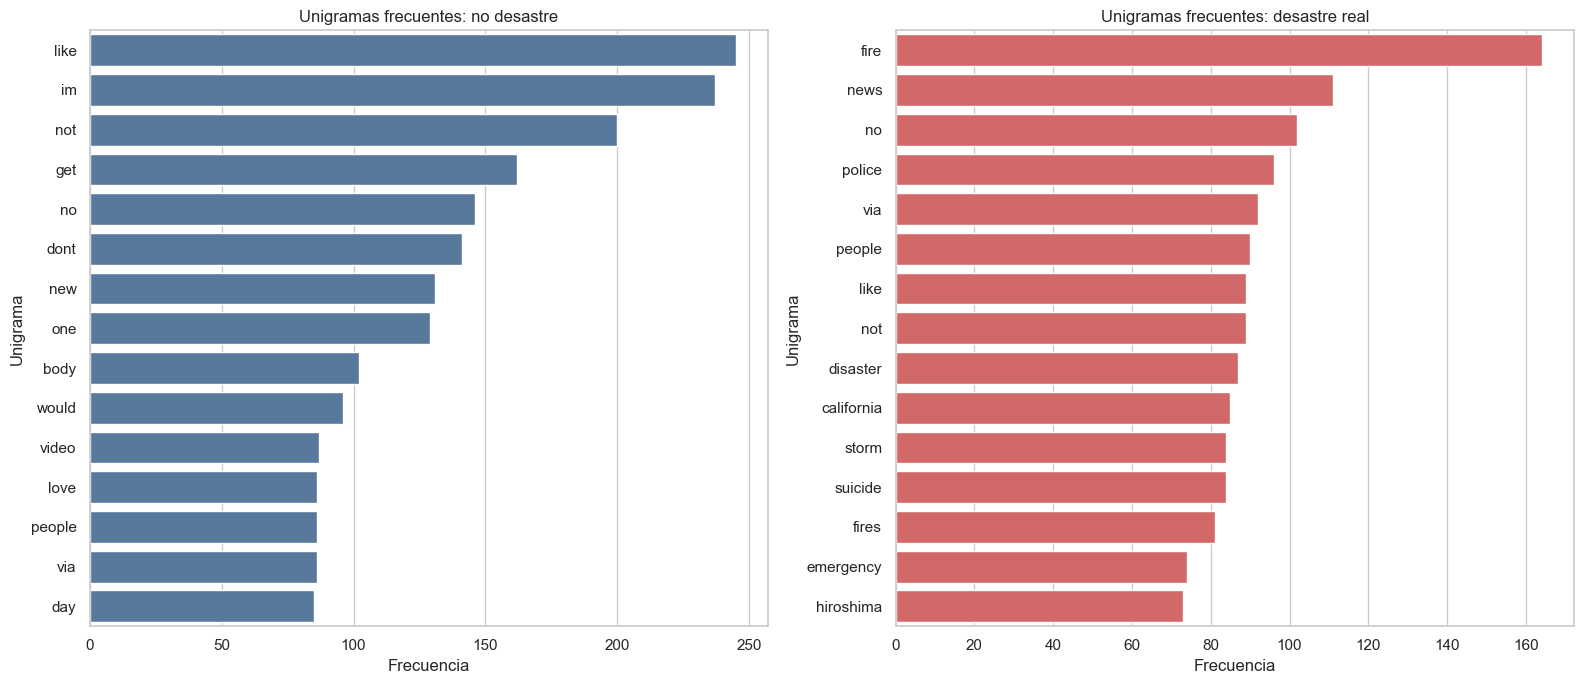

In [12]:
def calcular_ngrams_frecuentes(textos, ngram_range=(1, 1), cantidad=20):
    vectorizador_frecuencias = CountVectorizer(ngram_range=ngram_range)
    matriz = vectorizador_frecuencias.fit_transform(textos)
    frecuencias = matriz.sum(axis=0).A1
    tabla = pd.DataFrame({
        "ngrama": vectorizador_frecuencias.get_feature_names_out(),
        "frecuencia": frecuencias,
    })
    tabla["probabilidad (%)"] = frecuencias / frecuencias.sum() * 100
    return tabla.sort_values(["frecuencia", "ngrama"], ascending=[False, True]).head(cantidad).reset_index(drop=True)

def graficar_ngrams(tabla_no_desastre, tabla_desastre, nombre):
    fig, ejes = plt.subplots(1, 2, figsize=(16, 7))
    sns.barplot(data=tabla_no_desastre.head(15), x="frecuencia", y="ngrama", color=COLORES[0], ax=ejes[0])
    ejes[0].set_title(f"{nombre} frecuentes: no desastre")
    ejes[0].set_xlabel("Frecuencia")
    ejes[0].set_ylabel(nombre[:-1] if nombre.endswith("s") else nombre)
    sns.barplot(data=tabla_desastre.head(15), x="frecuencia", y="ngrama", color=COLORES[1], ax=ejes[1])
    ejes[1].set_title(f"{nombre} frecuentes: desastre real")
    ejes[1].set_xlabel("Frecuencia")
    ejes[1].set_ylabel(nombre[:-1] if nombre.endswith("s") else nombre)
    plt.tight_layout()
    plt.show()

unigramas_no_desastre = calcular_ngrams_frecuentes(datos_texto.loc[datos_texto.target == 0, "clean_text"], (1, 1))
unigramas_desastre = calcular_ngrams_frecuentes(datos_texto.loc[datos_texto.target == 1, "clean_text"], (1, 1))
display(unigramas_no_desastre)
display(unigramas_desastre)
graficar_ngrams(unigramas_no_desastre, unigramas_desastre, "Unigramas")

### Análisis de unigramas

Los unigramas muestran diferencias temáticas entre las dos categorías. En los tweets que no representan desastres predominan palabras asociadas con lenguaje cotidiano e informal, como `like`, `im`, `get`, `dont`, `love`, `day` y `know`. La palabra más frecuente fue `like`, con 245 apariciones y una probabilidad relativa aproximada de 0.718 %.

En los tweets relacionados con desastres aparecen términos directamente asociados con emergencias y sucesos graves. Entre ellos se encuentran `fire`, `police`, `disaster`, `storm`, `emergency`, `killed`, `crash`, `fires` y `nuclear`. La palabra más frecuente fue `fire`, con 164 apariciones y una probabilidad relativa aproximada de 0.614 %.

Las palabras `like`, `no`, `not`, `one`, `people` y `via` aparecen entre los 20 unigramas más frecuentes de ambas categorías. Su presencia compartida indica que no necesariamente permiten distinguir las categorías de manera aislada. Por ejemplo, `people` puede utilizarse tanto en una noticia sobre víctimas como en una conversación cotidiana.

La palabra `via` probablemente está relacionada con la forma de compartir noticias o publicaciones y no directamente con un desastre. También aparecen formas como `im`, `dont` y `cant`, producidas al eliminar los apóstrofes de las contracciones. Aunque estos términos podrían normalizarse adicionalmente, se conservaron porque representan diferencias en el estilo de escritura y podrían aportar información al clasificador.

Los resultados sugieren que varios unigramas pueden ayudar a distinguir los tweets sobre desastres. Sin embargo, las palabras individuales no siempre proporcionan suficiente contexto, por lo que es necesario explorar bigramas.

In [13]:
unigramas_compartidos = sorted(
    set(unigramas_no_desastre["ngrama"]).intersection(unigramas_desastre["ngrama"])
)
print("Unigramas presentes entre los 20 más frecuentes de ambas categorías:")
print(unigramas_compartidos)


Unigramas presentes entre los 20 más frecuentes de ambas categorías:
['like', 'no', 'not', 'one', 'people', 'via']


,ngrama,frecuencia,probabilidad (%)
0,liked video,30,0.099618
1,cross body,28,0.092977
2,body bagging,24,0.079695
3,looks like,21,0.069733
4,body bags,20,0.066412
5,burning buildings,19,0.063091
6,loud bang,19,0.063091
7,feel like,17,0.056450
8,first responders,17,0.056450
9,im not,17,0.056450


,ngrama,frecuencia,probabilidad (%)
0,suicide bomber,36,0.150081
1,suicide bombing,34,0.141743
2,burning buildings,28,0.116730
3,mass murder,26,0.108392
4,severe thunderstorm,26,0.108392
5,wild fires,24,0.100054
6,heat wave,23,0.095885
7,oil spill,23,0.095885
8,70 years,21,0.087547
9,natural disaster,20,0.083378


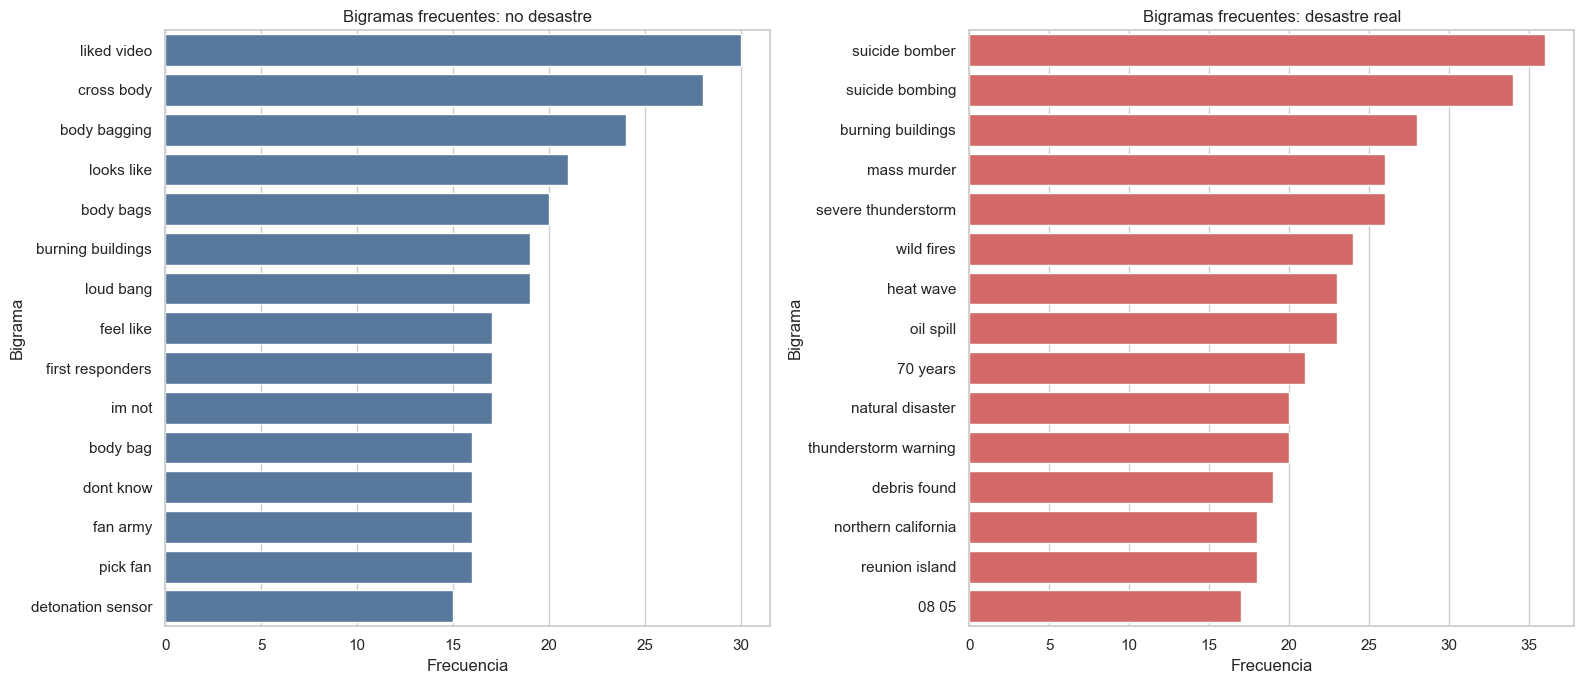

In [14]:
bigramas_no_desastre = calcular_ngrams_frecuentes(datos_texto.loc[datos_texto.target == 0, "clean_text"], (2, 2))
bigramas_desastre = calcular_ngrams_frecuentes(datos_texto.loc[datos_texto.target == 1, "clean_text"], (2, 2))
display(bigramas_no_desastre)
display(bigramas_desastre)
graficar_ngrams(bigramas_no_desastre, bigramas_desastre, "Bigramas")

### Análisis de bigramas

Los bigramas proporcionan más contexto que las palabras individuales. En los tweets clasificados como desastres reales aparecen expresiones directamente relacionadas con emergencias, como `suicide bomber`, `suicide bombing`, `severe thunderstorm`, `wild fires`, `heat wave`, `oil spill`, `natural disaster`, `thunderstorm warning`, `debris found` y `nuclear disaster`.

El bigrama más frecuente de esta categoría fue `suicide bomber`, con 36 apariciones y una probabilidad relativa aproximada de 0.150 %. Le siguió `suicide bombing`, con 34 apariciones. Estas combinaciones contienen más información que los unigramas `suicide` o `fire`, porque permiten identificar con mayor precisión el tipo de evento mencionado.

En los tweets que no representan desastres aparecen combinaciones asociadas con lenguaje cotidiano, como `liked video`, `looks like`, `feel like`, `im not` y `dont know`. No obstante, también se observaron expresiones relacionadas aparentemente con emergencias, como `body bags`, `first responders`, `war zone`, `detonation sensor` y `burning buildings`.

La presencia de expresiones relacionadas con emergencias en la categoría de no desastre evidencia la ambigüedad del lenguaje. Estos términos pueden emplearse de manera figurada, humorística, hipotética o dentro de conversaciones que no reportan un suceso real.

`burning buildings` fue el único bigrama presente entre los 20 más frecuentes de ambas categorías. En los tweets de desastre apareció 28 veces, mientras que en los tweets de no desastre apareció 19 veces. Por tanto, este bigrama no permite identificar por sí solo la categoría y necesita ser interpretado junto con el resto del tweet.

Los resultados justifican incorporar unigramas y bigramas en el modelo. Los unigramas proporcionan cobertura de vocabulario, mientras que los bigramas capturan expresiones con mayor contexto.

In [15]:
bigramas_compartidos = sorted(
    set(bigramas_no_desastre["ngrama"]).intersection(bigramas_desastre["ngrama"])
)
print("Bigramas presentes entre los 20 más frecuentes de ambas categorías:")
print(bigramas_compartidos)


Bigramas presentes entre los 20 más frecuentes de ambas categorías:
['burning buildings']


,ngrama,frecuencia,probabilidad (%)
0,pick fan army,16,0.061153
1,ignition knock detonation,15,0.057331
2,knock detonation sensor,15,0.057331
3,appears blast wind,13,0.049687
4,bang nearby appears,13,0.049687
5,blast wind neighbours,13,0.049687
6,breaking news unconfirmed,13,0.049687
7,heard loud bang,13,0.049687
8,loud bang nearby,13,0.049687
9,nearby appears blast,13,0.049687


,ngrama,frecuencia,probabilidad (%)
0,severe thunderstorm warning,20,0.094104
1,officer wounded suspect,15,0.070578
2,found reunion island,13,0.061168
3,police officer wounded,12,0.056463
4,suicide bomber detonated,12,0.056463
5,suicide bomber kills,12,0.056463
6,debris found reunion,11,0.051757
7,utc2015 08 05,11,0.051757
8,amid crisis famine,10,0.047052
9,bomber detonated bomb,10,0.047052


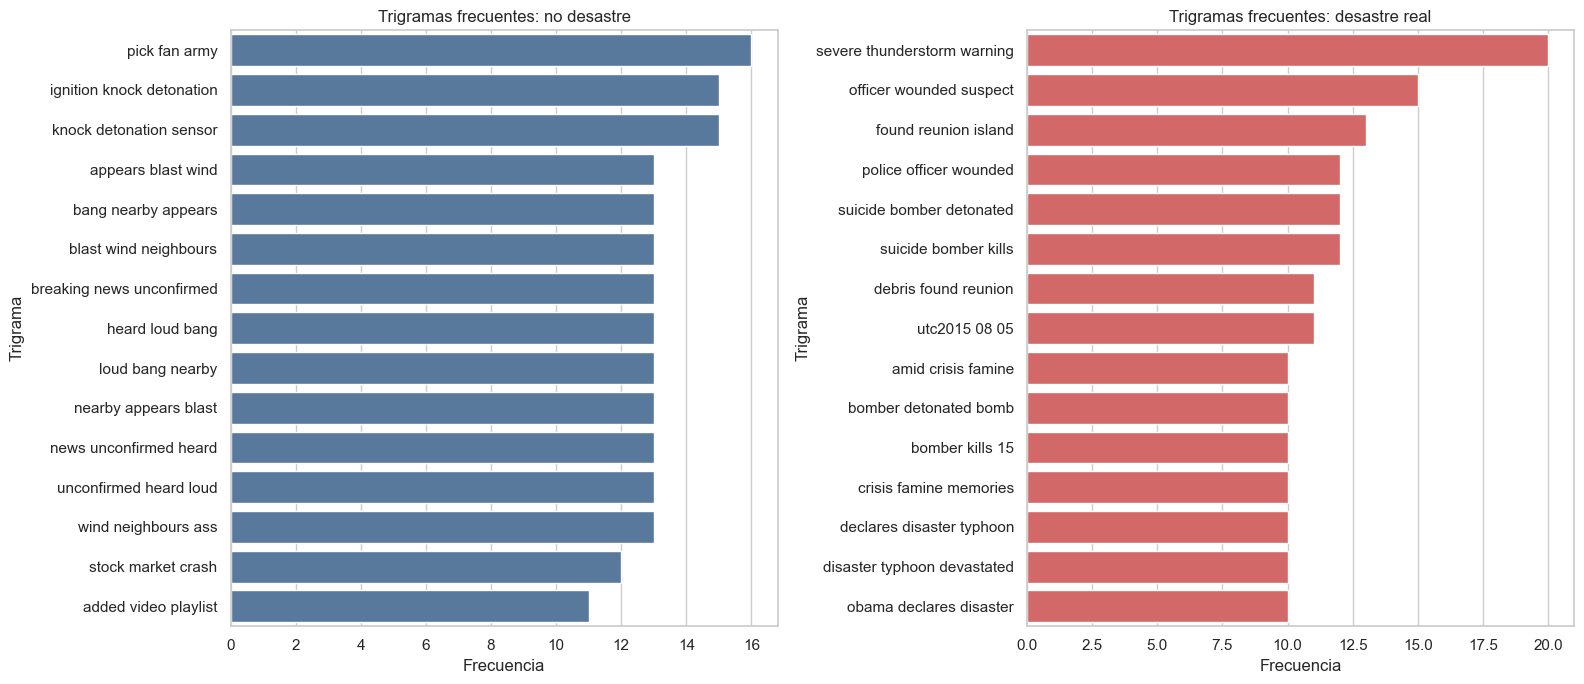

In [16]:
trigramas_no_desastre = calcular_ngrams_frecuentes(datos_texto.loc[datos_texto.target == 0, "clean_text"], (3, 3))
trigramas_desastre = calcular_ngrams_frecuentes(datos_texto.loc[datos_texto.target == 1, "clean_text"], (3, 3))
display(trigramas_no_desastre)
display(trigramas_desastre)
graficar_ngrams(trigramas_no_desastre, trigramas_desastre, "Trigramas")

### Conclusión del análisis de n-gramas

Los unigramas permiten identificar vocabulario relacionado con cada categoría. Palabras como `fire`, `police`, `disaster`, `storm`, `emergency`, `killed` y `crash` muestran una relación clara con los tweets sobre desastres. En cambio, palabras como `like`, `im`, `get`, `love` y `know` reflejan un lenguaje más cotidiano y aparecen con mayor frecuencia en los tweets que no corresponden a desastres.

Algunos términos aparecen en ambas categorías, por lo que una palabra relacionada con emergencias no garantiza que el tweet describa un desastre real. Los bigramas aportan más contexto mediante expresiones como `suicide bomber`, `severe thunderstorm`, `wild fires`, `heat wave`, `oil spill` y `nuclear disaster`.

También se exploraron trigramas. Estos muestran expresiones más específicas, como `severe thunderstorm warning`, pero tienen frecuencias menores y aumentan la cantidad de características. Por esa razón, su utilidad no se decide únicamente mediante las frecuencias: posteriormente se compara el rendimiento de TF-IDF con `ngram_range=(1, 2)` y `ngram_range=(1, 3)`.


## Nubes de palabras

Se generó una nube de palabras para cada categoría utilizando los textos preprocesados. El tamaño de cada palabra representa su frecuencia de aparición.

Las nubes permiten observar rápidamente las diferencias de vocabulario entre los tweets que representan desastres reales y aquellos que no representan desastres.

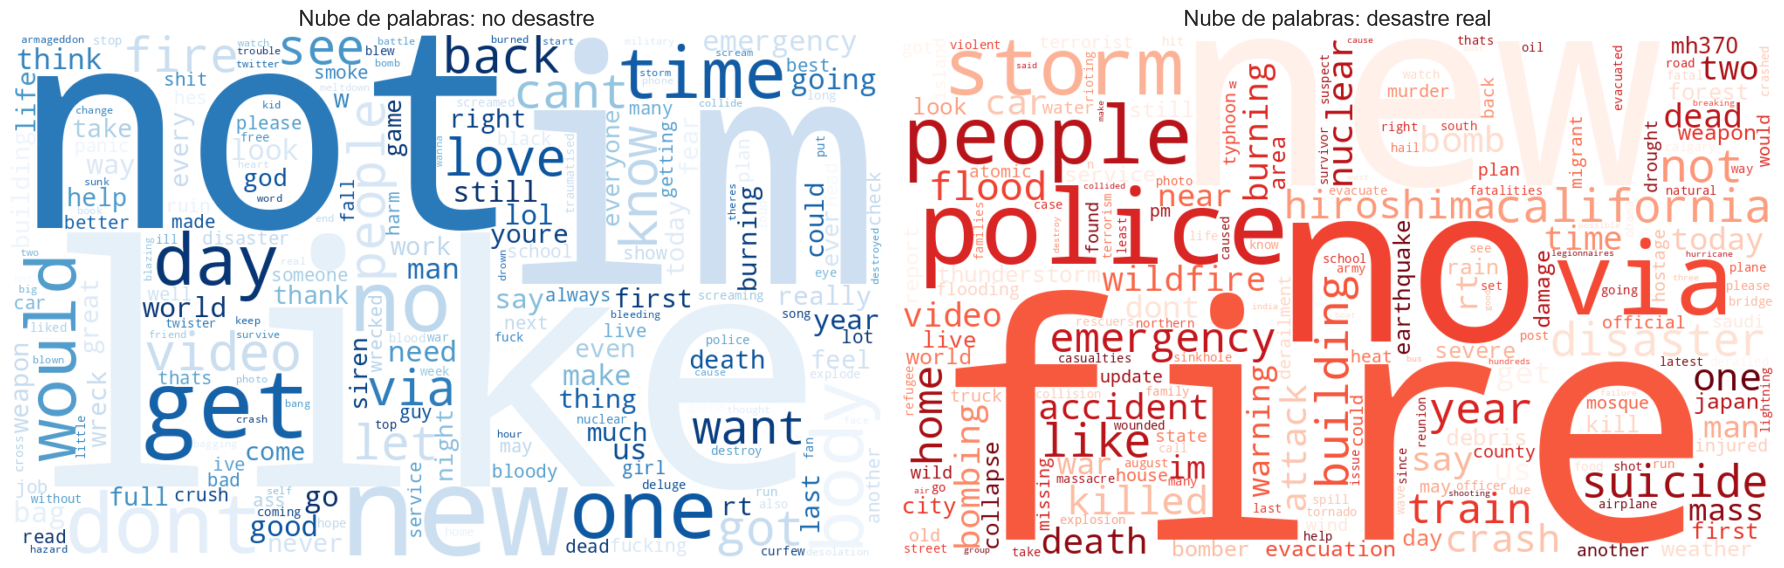

In [17]:
texto_no_desastre = " ".join(datos_texto.loc[datos_texto.target == 0, "clean_text"])
texto_desastre = " ".join(datos_texto.loc[datos_texto.target == 1, "clean_text"])

nube_no_desastre = WordCloud(
    width=1000, height=600, background_color="white", colormap="Blues",
    collocations=False, stopwords={"amp", "u"}, random_state=RANDOM_STATE,
).generate(texto_no_desastre)
nube_desastre = WordCloud(
    width=1000, height=600, background_color="white", colormap="Reds",
    collocations=False, stopwords={"amp", "u"}, random_state=RANDOM_STATE,
).generate(texto_desastre)

fig, ejes = plt.subplots(1, 2, figsize=(18, 8))
ejes[0].imshow(nube_no_desastre, interpolation="bilinear")
ejes[0].set_title("Nube de palabras: no desastre")
ejes[0].set_xlabel("Frecuencia visual relativa")
ejes[0].set_ylabel("Palabras")
ejes[0].axis("off")
ejes[1].imshow(nube_desastre, interpolation="bilinear")
ejes[1].set_title("Nube de palabras: desastre real")
ejes[1].set_xlabel("Frecuencia visual relativa")
ejes[1].set_ylabel("Palabras")
ejes[1].axis("off")
plt.tight_layout()
plt.show()

### Interpretación de las nubes de palabras

La nube correspondiente a los tweets que no representan desastres contiene principalmente vocabulario cotidiano, como `like`, `video`, `body`, `time`, `people`, `see`, `know`, `love`, `back` y `want`. Esto coincide con las frecuencias obtenidas en el análisis de unigramas.

En la categoría de desastres reales destacan palabras como `fire`, `disaster`, `emergency`, `people`, `police`, `storm`, `killed`, `flood`, `bomb`, `death`, `wildfire` y `warning`. Estas palabras se relacionan con incendios, fenómenos naturales, accidentes, violencia y situaciones de emergencia.

Algunas palabras, como `people`, `one`, `time` y `year`, aparecen visualmente en ambas categorías. Por sí solas, estas palabras no permiten distinguir si un tweet informa sobre un desastre real. Su significado depende de las palabras que las acompañan, lo cual respalda el uso conjunto de unigramas y bigramas en el modelo.

Durante la construcción de las nubes se excluyeron los términos `amp` y `u`, debido a que eran residuos de entidades HTML y problemas de codificación, respectivamente. Estos elementos no tienen valor semántico para el análisis.

Las nubes permiten identificar visualmente diferencias entre las categorías, pero no sustituyen el análisis cuantitativo de frecuencias y probabilidades realizado anteriormente.

## Modelos de clasificación

Primero se conserva la regresión logística con `CountVectorizer` como línea base, utilizando unigramas y bigramas. Después se comparan alternativas con TF-IDF, Naive Bayes multinomial, SVM lineal y una configuración que también incorpora trigramas.

El conjunto de datos se divide en 80 % para entrenamiento y 20 % para prueba. La división es estratificada para conservar la proporción de las categorías y se reutiliza en todos los experimentos.

Para evitar fuga de información, cada vectorizador se ajusta únicamente con los textos de entrenamiento. Los textos de prueba se transforman utilizando el vocabulario aprendido durante el entrenamiento. El criterio principal de selección es el F1-score de la clase desastre; como criterios secundarios se utilizan el recall de desastre y el accuracy.


In [18]:
indices = np.arange(len(datos_texto))
indices_entrenamiento, indices_prueba = train_test_split(
    indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=datos_texto["target"],
)

texto_entrenamiento = datos_texto.loc[indices_entrenamiento, "clean_text"]
texto_prueba = datos_texto.loc[indices_prueba, "clean_text"]
target_entrenamiento = datos_texto.loc[indices_entrenamiento, "target"]
target_prueba = datos_texto.loc[indices_prueba, "target"]

print("Tweets totales:", len(datos_texto))
print("Tweets de entrenamiento:", len(indices_entrenamiento))
print("Tweets de prueba:", len(indices_prueba))
display(pd.DataFrame({
    "entrenamiento (%)": target_entrenamiento.value_counts(normalize=True).sort_index() * 100,
    "prueba (%)": target_prueba.value_counts(normalize=True).sort_index() * 100,
}).rename(index=ETIQUETAS).round(2))

Tweets totales: 6737
Tweets de entrenamiento: 5389
Tweets de prueba: 1348


,entrenamiento (%),prueba (%)
target,,
No desastre,59.36,59.35
Desastre real,40.64,40.65


In [19]:
accuracy_modelo_mayoritario = target_prueba.value_counts(normalize=True).max()
print("Accuracy del modelo mayoritario:", round(accuracy_modelo_mayoritario, 4))
print(
    "Este valor sirve como referencia mínima: un clasificador útil debe superarlo "
    "y también mantener métricas adecuadas para la clase desastre."
)


Accuracy del modelo mayoritario: 0.5935
Este valor sirve como referencia mínima: un clasificador útil debe superarlo y también mantener métricas adecuadas para la clase desastre.


In [20]:
def evaluar_predicciones(nombre, y_entrenamiento, pred_entrenamiento, y_prueba, pred_prueba):
    accuracy_entrenamiento = accuracy_score(y_entrenamiento, pred_entrenamiento)
    accuracy_prueba = accuracy_score(y_prueba, pred_prueba)
    return {
        "modelo": nombre,
        "accuracy entrenamiento": accuracy_entrenamiento,
        "accuracy": accuracy_prueba,
        "precision desastre": precision_score(y_prueba, pred_prueba, zero_division=0),
        "recall desastre": recall_score(y_prueba, pred_prueba, zero_division=0),
        "F1 desastre": f1_score(y_prueba, pred_prueba, zero_division=0),
        "F1 macro": f1_score(y_prueba, pred_prueba, average="macro", zero_division=0),
        "diferencia entrenamiento-prueba": accuracy_entrenamiento - accuracy_prueba,
    }

configuraciones_modelos = [
    (
        "Regresión logística + Count (1,2)",
        CountVectorizer(ngram_range=(1, 2), min_df=2),
        LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE),
    ),
    (
        "Regresión logística + TF-IDF (1,2)",
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE),
    ),
    (
        "Naive Bayes multinomial + TF-IDF (1,2)",
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        MultinomialNB(),
    ),
    (
        "SVM lineal + TF-IDF (1,2)",
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LinearSVC(random_state=RANDOM_STATE),
    ),
    (
        "Regresión logística + TF-IDF (1,3)",
        TfidfVectorizer(ngram_range=(1, 3), min_df=2, sublinear_tf=True),
        LogisticRegression(solver="liblinear", max_iter=1000, random_state=RANDOM_STATE),
    ),
]

resultados_modelos = []
artefactos_modelos = {}
for nombre_modelo, vectorizador_experimento, clasificador_experimento in configuraciones_modelos:
    matriz_entrenamiento = vectorizador_experimento.fit_transform(texto_entrenamiento)
    matriz_prueba = vectorizador_experimento.transform(texto_prueba)
    clasificador_experimento.fit(matriz_entrenamiento, target_entrenamiento)
    pred_entrenamiento = clasificador_experimento.predict(matriz_entrenamiento)
    pred_prueba = clasificador_experimento.predict(matriz_prueba)
    resultados_modelos.append(evaluar_predicciones(
        nombre_modelo, target_entrenamiento, pred_entrenamiento, target_prueba, pred_prueba
    ))
    artefactos_modelos[nombre_modelo] = {
        "vectorizador": vectorizador_experimento,
        "clasificador": clasificador_experimento,
        "matriz entrenamiento": matriz_entrenamiento,
        "matriz prueba": matriz_prueba,
        "predicción prueba": pred_prueba,
        "matriz de confusión": confusion_matrix(target_prueba, pred_prueba),
    }

tabla_modelos = pd.DataFrame(resultados_modelos).sort_values(
    ["F1 desastre", "recall desastre", "accuracy"], ascending=False
).reset_index(drop=True)
display(tabla_modelos.style.format(precision=4))

,modelo,accuracy entrenamiento,accuracy,precision desastre,recall desastre,F1 desastre,F1 macro,diferencia entrenamiento-prueba
0,"SVM lineal + TF-IDF (1,2)",0.9705,0.7782,0.7546,0.6734,0.7117,0.7657,0.1923
1,"Regresión logística + Count (1,2)",0.9482,0.7826,0.7815,0.6460,0.7073,0.7672,0.1656
2,"Regresión logística + TF-IDF (1,2)",0.8829,0.7893,0.8173,0.6204,0.7054,0.7707,0.0936
3,"Regresión logística + TF-IDF (1,3)",0.8831,0.7886,0.8153,0.6204,0.7047,0.7700,0.0945
4,"Naive Bayes multinomial + TF-IDF (1,2)",0.8720,0.7908,0.8537,0.5858,0.6948,0.7678,0.0812


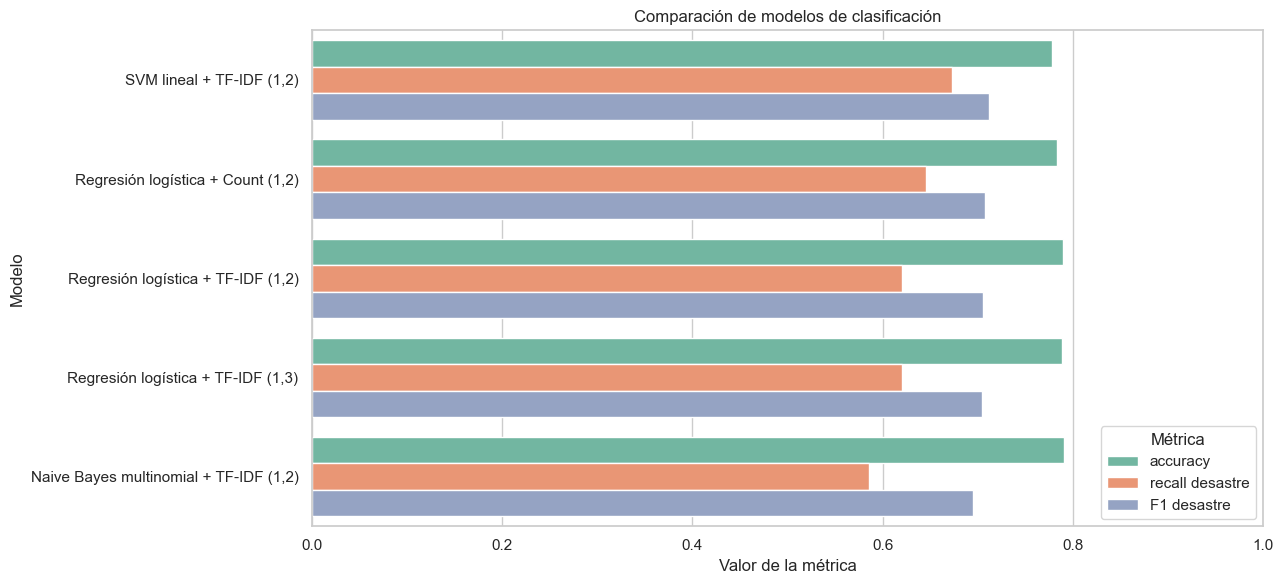

Mejor modelo según F1 de desastre: SVM lineal + TF-IDF (1,2)


In [21]:
metricas_grafica = ["accuracy", "recall desastre", "F1 desastre"]
tabla_modelos_larga = tabla_modelos.melt(
    id_vars="modelo", value_vars=metricas_grafica,
    var_name="métrica", value_name="valor",
)
plt.figure(figsize=(13, 6))
sns.barplot(data=tabla_modelos_larga, x="valor", y="modelo", hue="métrica", palette="Set2")
plt.title("Comparación de modelos de clasificación")
plt.xlabel("Valor de la métrica")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.legend(title="Métrica", loc="lower right")
plt.tight_layout()
plt.show()

nombre_mejor_modelo = tabla_modelos.loc[0, "modelo"]
artefactos_mejor_texto = artefactos_modelos[nombre_mejor_modelo]
vectorizador_mejor_texto = artefactos_mejor_texto["vectorizador"]
clasificador_mejor_texto = artefactos_mejor_texto["clasificador"]
prediccion_mejor_texto = artefactos_mejor_texto["predicción prueba"]

print("Mejor modelo según F1 de desastre:", nombre_mejor_modelo)

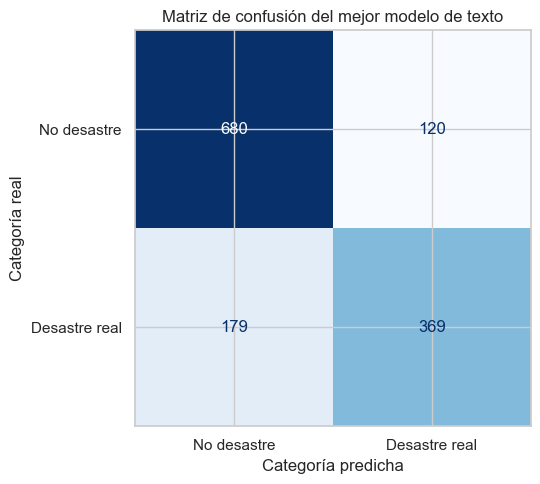


### Selección y sobreajuste

El modelo seleccionado es **SVM lineal + TF-IDF (1,2)**, porque obtuvo el mayor F1 de desastre (0.7117). Como criterios secundarios se consideraron el recall de desastre (0.6734) y el accuracy (0.7782). La diferencia entre accuracy de entrenamiento y prueba fue 0.1923.

La línea base reprodujo una diferencia de 0.1656 entre entrenamiento y prueba. La regresión logística con TF-IDF la redujo a 0.0936, lo que indica menor sobreajuste, aunque no alcanzó el mayor F1 de desastre. SVM obtuvo una diferencia de 0.1923; por tanto, su mejora en F1 viene acompañada de mayor separación entre entrenamiento y prueba y debe interpretarse con cautela.

Los 179 falsos negativos del mejor modelo son especialmente importantes: corresponden a desastres reales que no fueron detectados.


In [22]:
fig, eje = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    target_prueba,
    prediccion_mejor_texto,
    display_labels=["No desastre", "Desastre real"],
    cmap="Blues",
    colorbar=False,
    ax=eje,
)
eje.set_title("Matriz de confusión del mejor modelo de texto")
eje.set_xlabel("Categoría predicha")
eje.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()

fila_mejor = tabla_modelos.iloc[0]
matriz_mejor = confusion_matrix(target_prueba, prediccion_mejor_texto)
falsos_negativos = int(matriz_mejor[1, 0])
tabla_por_nombre = tabla_modelos.set_index("modelo")
diferencia_base = tabla_por_nombre.loc["Regresión logística + Count (1,2)", "diferencia entrenamiento-prueba"]
diferencia_tfidf = tabla_por_nombre.loc["Regresión logística + TF-IDF (1,2)", "diferencia entrenamiento-prueba"]
diferencia_svm = tabla_por_nombre.loc["SVM lineal + TF-IDF (1,2)", "diferencia entrenamiento-prueba"]
display(Markdown(f'''
### Selección y sobreajuste

El modelo seleccionado es **{nombre_mejor_modelo}**, porque obtuvo el mayor F1 de desastre ({fila_mejor['F1 desastre']:.4f}). Como criterios secundarios se consideraron el recall de desastre ({fila_mejor['recall desastre']:.4f}) y el accuracy ({fila_mejor['accuracy']:.4f}). La diferencia entre accuracy de entrenamiento y prueba fue {fila_mejor['diferencia entrenamiento-prueba']:.4f}.

La línea base reprodujo una diferencia de {diferencia_base:.4f} entre entrenamiento y prueba. La regresión logística con TF-IDF la redujo a {diferencia_tfidf:.4f}, lo que indica menor sobreajuste, aunque no alcanzó el mayor F1 de desastre. SVM obtuvo una diferencia de {diferencia_svm:.4f}; por tanto, su mejora en F1 viene acompañada de mayor separación entre entrenamiento y prueba y debe interpretarse con cautela.

Los {falsos_negativos} falsos negativos del mejor modelo son especialmente importantes: corresponden a desastres reales que no fueron detectados.
'''))

In [23]:
fila_tfidf_12 = tabla_modelos.set_index("modelo").loc["Regresión logística + TF-IDF (1,2)"]
fila_tfidf_13 = tabla_modelos.set_index("modelo").loc["Regresión logística + TF-IDF (1,3)"]
diferencia_f1_trigramas = fila_tfidf_13["F1 desastre"] - fila_tfidf_12["F1 desastre"]
decision_trigramas = "sí aportaron una mejora" if diferencia_f1_trigramas > 0 else "no mejoraron"
display(Markdown(f'''
### Evaluación de trigramas

Con TF-IDF, el rango `(1, 2)` obtuvo F1 de desastre de {fila_tfidf_12['F1 desastre']:.4f}, mientras que `(1, 3)` obtuvo {fila_tfidf_13['F1 desastre']:.4f}. La diferencia fue {diferencia_f1_trigramas:+.4f}; por tanto, los trigramas **{decision_trigramas}** en este experimento.

Aunque añaden contexto, también generan muchas secuencias poco frecuentes. Su inclusión solo se justifica si la mejora observada compensa ese aumento de dimensionalidad; no se asume que ayudan por el simple hecho de contener más palabras.
'''))


### Evaluación de trigramas

Con TF-IDF, el rango `(1, 2)` obtuvo F1 de desastre de 0.7054, mientras que `(1, 3)` obtuvo 0.7047. La diferencia fue -0.0007; por tanto, los trigramas **no mejoraron** en este experimento.

Aunque añaden contexto, también generan muchas secuencias poco frecuentes. Su inclusión solo se justifica si la mejora observada compensa ese aumento de dimensionalidad; no se asume que ayudan por el simple hecho de contener más palabras.


## Análisis de sentimiento con VADER

VADER se aplica al texto original, no a `clean_text`, para conservar mayúsculas, signos, negaciones, emoticonos e intensificadores. `negatividad` corresponde al componente `neg`, en escala de 0 a 1.

Para contar palabras se tokeniza cada tweet y se consulta el lexicón de VADER: una puntuación mayor que cero cuenta como palabra positiva y una menor que cero como negativa. Este conteo es léxico y no captura por completo el contexto, la ironía ni expresiones fuera del vocabulario.

In [24]:
analizador_sentimiento = SentimentIntensityAnalyzer()

def obtener_sentimiento(texto):
    puntuaciones = analizador_sentimiento.polarity_scores(str(texto))
    compuesto = puntuaciones["compound"]
    if compuesto >= 0.05:
        categoria = "Positivo"
    elif compuesto <= -0.05:
        categoria = "Negativo"
    else:
        categoria = "Neutral"

    tokens = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", str(texto).lower())
    conteo_positivo = sum(analizador_sentimiento.lexicon.get(token, 0) > 0 for token in tokens)
    conteo_negativo = sum(analizador_sentimiento.lexicon.get(token, 0) < 0 for token in tokens)
    return pd.Series({
        "sentiment_positive": puntuaciones["pos"],
        "sentiment_negative": puntuaciones["neg"],
        "sentiment_neutral": puntuaciones["neu"],
        "sentiment_compound": compuesto,
        "sentiment_category": categoria,
        "negatividad": puntuaciones["neg"],
        "positive_word_count": conteo_positivo,
        "negative_word_count": conteo_negativo,
    })

columnas_sentimiento = datos_texto["text"].apply(obtener_sentimiento)
datos_texto = pd.concat([datos_texto, columnas_sentimiento], axis=1)
display(datos_texto[["text", "sentiment_category", "sentiment_compound", "negatividad"]].head())

,text,sentiment_category,sentiment_compound,negatividad
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,Positivo,0.2732,0.000
1,Forest fire near La Ronge Sask. Canada,Negativo,-0.3400,0.286
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,Negativo,-0.2960,0.095
3,"13,000 people receive #wildfires evacuation orders in California",Neutral,0.0000,0.000
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,Neutral,0.0000,0.000


,sentimiento,cantidad,porcentaje
0,Positivo,1776,26.36%
1,Negativo,3247,48.20%
2,Neutral,1714,25.44%


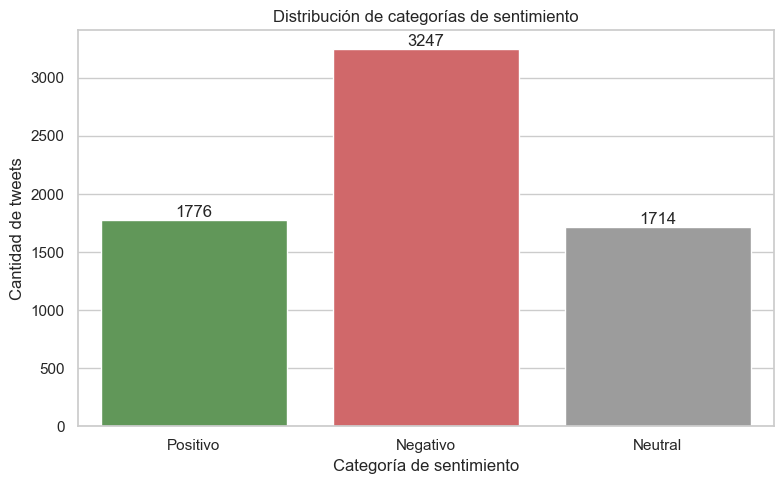

In [25]:
orden_sentimiento = ["Positivo", "Negativo", "Neutral"]
resumen_sentimiento = (
    datos_texto["sentiment_category"].value_counts().reindex(orden_sentimiento, fill_value=0)
    .rename_axis("sentimiento").reset_index(name="cantidad")
)
resumen_sentimiento["porcentaje"] = resumen_sentimiento["cantidad"] / len(datos_texto) * 100
display(resumen_sentimiento.style.format({"porcentaje": "{:.2f}%"}))

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=resumen_sentimiento, x="sentimiento", y="cantidad",
    hue="sentimiento", palette={"Positivo": "#59A14F", "Negativo": "#E15759", "Neutral": "#9C9C9C"},
    legend=False,
)
ax.set_title("Distribución de categorías de sentimiento")
ax.set_xlabel("Categoría de sentimiento")
ax.set_ylabel("Cantidad de tweets")
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.show()

,media,mediana,cantidad
target,,,
No desastre,0.1315,0.0900,3999
Desastre real,0.1725,0.1560,2738


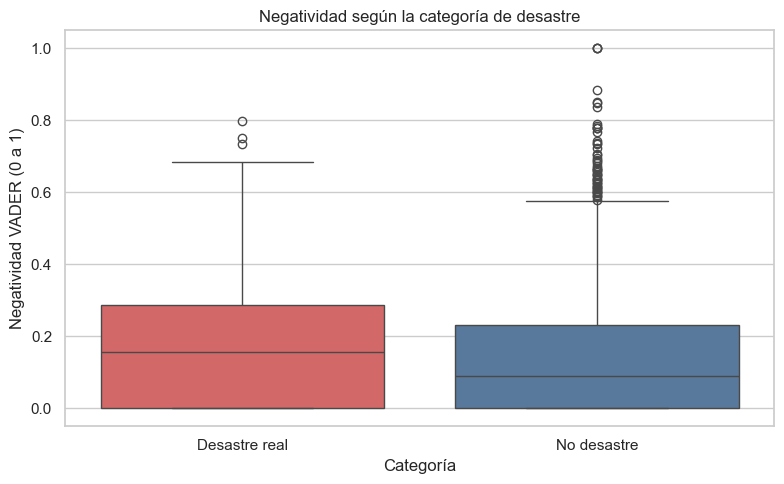


### Interpretación del sentimiento

La negatividad media fue 0.1725 en tweets de desastre real y 0.1315 en tweets de no desastre, una diferencia de +0.0410.

**¿Los tweets que hablan de desastres reales son más negativos que los tweets que no hablan de desastres?** Según la media observada, **sí**. Esta es una asociación descriptiva del corpus; VADER puede interpretar de forma imperfecta noticias, ironía, abreviaturas y contexto de dominio.


In [26]:
resumen_negatividad = datos_texto.groupby("target")["negatividad"].agg(["mean", "median", "count"])
resumen_negatividad = resumen_negatividad.rename(columns={"mean": "media", "median": "mediana", "count": "cantidad"})
resumen_negatividad.index = resumen_negatividad.index.map(ETIQUETAS)
display(resumen_negatividad.style.format({"media": "{:.4f}", "mediana": "{:.4f}"}))

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=datos_texto.assign(categoría=datos_texto["target"].map(ETIQUETAS)),
    x="categoría", y="negatividad", hue="categoría",
    palette={"No desastre": COLORES[0], "Desastre real": COLORES[1]}, legend=False,
)
plt.title("Negatividad según la categoría de desastre")
plt.xlabel("Categoría")
plt.ylabel("Negatividad VADER (0 a 1)")
plt.tight_layout()
plt.show()

media_no_desastre = resumen_negatividad.loc["No desastre", "media"]
media_desastre = resumen_negatividad.loc["Desastre real", "media"]
respuesta_negatividad = "sí" if media_desastre > media_no_desastre else "no"
display(Markdown(f'''
### Interpretación del sentimiento

La negatividad media fue {media_desastre:.4f} en tweets de desastre real y {media_no_desastre:.4f} en tweets de no desastre, una diferencia de {media_desastre - media_no_desastre:+.4f}.

**¿Los tweets que hablan de desastres reales son más negativos que los tweets que no hablan de desastres?** Según la media observada, **{respuesta_negatividad}**. Esta es una asociación descriptiva del corpus; VADER puede interpretar de forma imperfecta noticias, ironía, abreviaturas y contexto de dominio.
'''))

## Tweets con sentimiento extremo

Los diez tweets más negativos se ordenan por `sentiment_compound` ascendente y, en caso de empate, por `negatividad` descendente. Los más positivos usan `sentiment_compound` descendente y `sentiment_positive` como segundo criterio.

In [27]:
columnas_extremos = [
    "text", "target", "categoría", "sentiment_compound", "negatividad",
    "positive_word_count", "negative_word_count",
]
datos_texto["categoría"] = datos_texto["target"].map(ETIQUETAS)

tweets_mas_negativos = datos_texto.sort_values(
    ["sentiment_compound", "negatividad"], ascending=[True, False]
).head(10)[columnas_extremos]
tweets_mas_positivos = datos_texto.sort_values(
    ["sentiment_compound", "sentiment_positive"], ascending=[False, False]
).head(10)[columnas_extremos]

print("Diez tweets más negativos")
display(tweets_mas_negativos)
print("Diez tweets más positivos")
display(tweets_mas_positivos)

conteo_negativos = tweets_mas_negativos["categoría"].value_counts()
conteo_positivos = tweets_mas_positivos["categoría"].value_counts()
display(Markdown(f'''
### Interpretación de los extremos

Entre los diez tweets más negativos hay {conteo_negativos.get('Desastre real', 0)} de desastre real y {conteo_negativos.get('No desastre', 0)} de no desastre. Entre los diez más positivos hay {conteo_positivos.get('Desastre real', 0)} de desastre real y {conteo_positivos.get('No desastre', 0)} de no desastre.

Los extremos ayudan a inspeccionar el comportamiento de VADER, pero una puntuación intensa no garantiza que el evento sea real: sentimiento y clasificación de desastre son objetivos diferentes.
'''))

Diez tweets más negativos


,text,target,categoría,sentiment_compound,negatividad,positive_word_count,negative_word_count
6632,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,0,No desastre,-0.9883,1.000,0,13
5671,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead\nThis is ridiculous,1,Desastre real,-0.9686,0.542,0,5
5669,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl,1,Desastre real,-0.9623,0.536,1,5
5651,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp,1,Desastre real,-0.9595,0.583,1,5
5665,17 killed in SÛªArabia mosque suicide bombing\n\nA suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX,1,Desastre real,-0.9552,0.579,0,4
2664,at the lake \n*sees a dead fish*\nme: poor little guy i wonder what happened\nashley: idk maybe it drowned\n wtf ????????,0,No desastre,-0.9549,0.538,0,5
416,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO,1,Desastre real,-0.9538,0.536,0,5
1382,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust,1,Desastre real,-0.9524,0.566,1,7
6037,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there,1,Desastre real,-0.9500,0.481,0,4
6137,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.,1,Desastre real,-0.9493,0.481,1,4


Diez tweets más positivos


,text,target,categoría,sentiment_compound,negatividad,positive_word_count,negative_word_count
6198,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1\nI would Love Love Love!! To win,0,No desastre,0.9730,0.000,6,0
5782,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!,0,No desastre,0.9564,0.049,5,1
5574,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.,1,Desastre real,0.9471,0.000,5,0
2881,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.,0,No desastre,0.9423,0.084,5,1
6006,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song,0,No desastre,0.9394,0.000,3,1
5577,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite &amp; Share,0,No desastre,0.9376,0.000,5,0
2243,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you :),1,Desastre real,0.9356,0.000,4,0
894,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,0,No desastre,0.9345,0.061,4,0
5808,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????,0,No desastre,0.9344,0.000,5,0
5425,Super sweet and beautiful :) https://t.co/TUi9uwBvVp,0,No desastre,0.9300,0.000,3,0



### Interpretación de los extremos

Entre los diez tweets más negativos hay 8 de desastre real y 2 de no desastre. Entre los diez más positivos hay 2 de desastre real y 8 de no desastre.

Los extremos ayudan a inspeccionar el comportamiento de VADER, pero una puntuación intensa no garantiza que el evento sea real: sentimiento y clasificación de desastre son objetivos diferentes.


## Mejor modelo con y sin negatividad

Se reutilizan el mismo algoritmo, parámetros, vectorizador ya ajustado y división. La única diferencia es añadir la columna numérica `negatividad` mediante una matriz dispersa. Así, la comparación atribuye cualquier cambio exclusivamente a esa variable.

In [28]:
negatividad_entrenamiento = datos_texto.loc[indices_entrenamiento, "negatividad"].to_numpy().reshape(-1, 1)
negatividad_prueba = datos_texto.loc[indices_prueba, "negatividad"].to_numpy().reshape(-1, 1)

matriz_mejor_entrenamiento = artefactos_mejor_texto["matriz entrenamiento"]
matriz_mejor_prueba = artefactos_mejor_texto["matriz prueba"]
matriz_entrenamiento_negatividad = hstack([matriz_mejor_entrenamiento, negatividad_entrenamiento]).tocsr()
matriz_prueba_negatividad = hstack([matriz_mejor_prueba, negatividad_prueba]).tocsr()

clasificador_con_negatividad = clone(clasificador_mejor_texto)
clasificador_con_negatividad.fit(matriz_entrenamiento_negatividad, target_entrenamiento)
prediccion_entrenamiento_negatividad = clasificador_con_negatividad.predict(matriz_entrenamiento_negatividad)
prediccion_prueba_negatividad = clasificador_con_negatividad.predict(matriz_prueba_negatividad)

metricas_texto = evaluar_predicciones(
    "Solo texto", target_entrenamiento,
    clasificador_mejor_texto.predict(matriz_mejor_entrenamiento),
    target_prueba, prediccion_mejor_texto,
)
metricas_negatividad = evaluar_predicciones(
    "Texto y negatividad", target_entrenamiento,
    prediccion_entrenamiento_negatividad,
    target_prueba, prediccion_prueba_negatividad,
)

metricas_comparacion = ["accuracy", "precision desastre", "recall desastre", "F1 desastre", "F1 macro"]
tabla_comparacion = pd.DataFrame({
    "métrica": metricas_comparacion,
    "valor original": [metricas_texto[m] for m in metricas_comparacion],
    "valor nuevo": [metricas_negatividad[m] for m in metricas_comparacion],
})
tabla_comparacion["diferencia absoluta"] = tabla_comparacion["valor nuevo"] - tabla_comparacion["valor original"]
tabla_comparacion["diferencia en puntos porcentuales"] = tabla_comparacion["diferencia absoluta"] * 100
display(tabla_comparacion.style.format({
    "valor original": "{:.4f}", "valor nuevo": "{:.4f}",
    "diferencia absoluta": "{:+.4f}", "diferencia en puntos porcentuales": "{:+.2f}",
}))

,métrica,valor original,valor nuevo,diferencia absoluta,diferencia en puntos porcentuales
0,accuracy,0.7782,0.7834,+0.0052,+0.52
1,precision desastre,0.7546,0.7591,+0.0045,+0.45
2,recall desastre,0.6734,0.6843,+0.0109,+1.09
3,F1 desastre,0.7117,0.7198,+0.0081,+0.81
4,F1 macro,0.7657,0.7716,+0.0059,+0.59


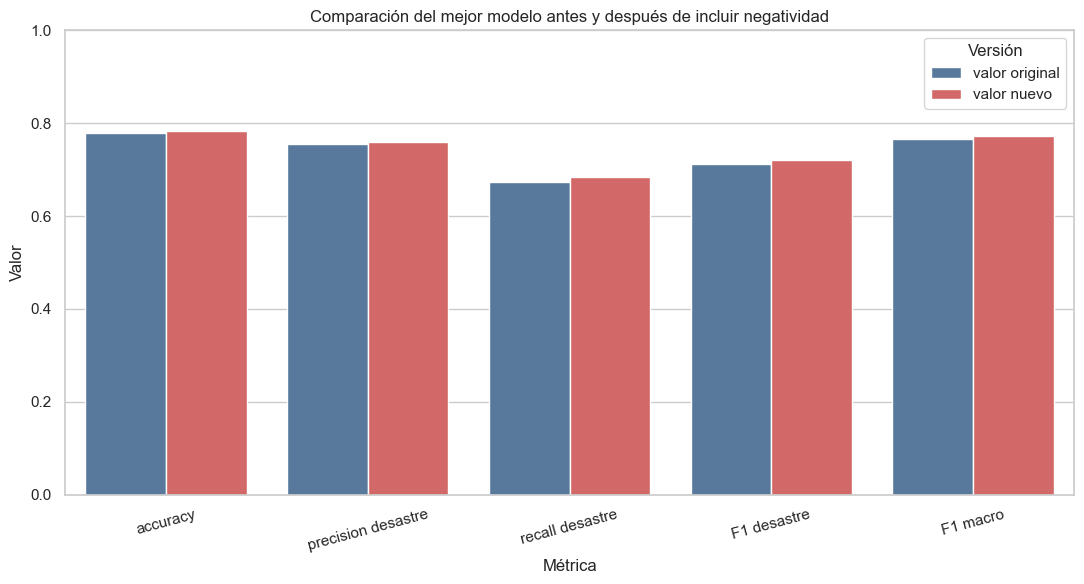


### Resultado de añadir negatividad

**¿La negatividad mejoró el modelo?** Según el criterio principal, **sí**: el F1 de desastre cambió de 0.7117 a 0.7198, una diferencia de +0.0081 (+0.81 puntos porcentuales).

- Métricas que mejoraron: accuracy, precision desastre, recall desastre, F1 desastre, F1 macro.
- Métricas que empeoraron: ninguna.
- Con un umbral práctico de 0.5 puntos porcentuales en F1, **sí** se justifica incluir la variable por magnitud de mejora.

Este umbral es una regla práctica explícita, no una prueba de significancia. Una validación cruzada sería necesaria para afirmar que una diferencia pequeña es estable.


In [29]:
tabla_comparacion_grafica = tabla_comparacion.melt(
    id_vars="métrica", value_vars=["valor original", "valor nuevo"],
    var_name="versión", value_name="valor",
)
plt.figure(figsize=(11, 6))
sns.barplot(data=tabla_comparacion_grafica, x="métrica", y="valor", hue="versión", palette=[COLORES[0], COLORES[1]])
plt.title("Comparación del mejor modelo antes y después de incluir negatividad")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Versión")
plt.tight_layout()
plt.show()

diferencia_f1_negatividad = metricas_negatividad["F1 desastre"] - metricas_texto["F1 desastre"]
justifica = diferencia_f1_negatividad >= 0.005
usar_negatividad = justifica
mejoro_texto = "sí" if diferencia_f1_negatividad > 0 else "no"
metricas_mejoraron = tabla_comparacion.loc[tabla_comparacion["diferencia absoluta"] > 0, "métrica"].tolist()
metricas_empeoraron = tabla_comparacion.loc[tabla_comparacion["diferencia absoluta"] < 0, "métrica"].tolist()

display(Markdown(f'''
### Resultado de añadir negatividad

**¿La negatividad mejoró el modelo?** Según el criterio principal, **{mejoro_texto}**: el F1 de desastre cambió de {metricas_texto['F1 desastre']:.4f} a {metricas_negatividad['F1 desastre']:.4f}, una diferencia de {diferencia_f1_negatividad:+.4f} ({diferencia_f1_negatividad * 100:+.2f} puntos porcentuales).

- Métricas que mejoraron: {', '.join(metricas_mejoraron) if metricas_mejoraron else 'ninguna'}.
- Métricas que empeoraron: {', '.join(metricas_empeoraron) if metricas_empeoraron else 'ninguna'}.
- Con un umbral práctico de 0.5 puntos porcentuales en F1, **{'sí' if justifica else 'no'}** se justifica incluir la variable por magnitud de mejora.

Este umbral es una regla práctica explícita, no una prueba de significancia. Una validación cruzada sería necesaria para afirmar que una diferencia pequeña es estable.
'''))

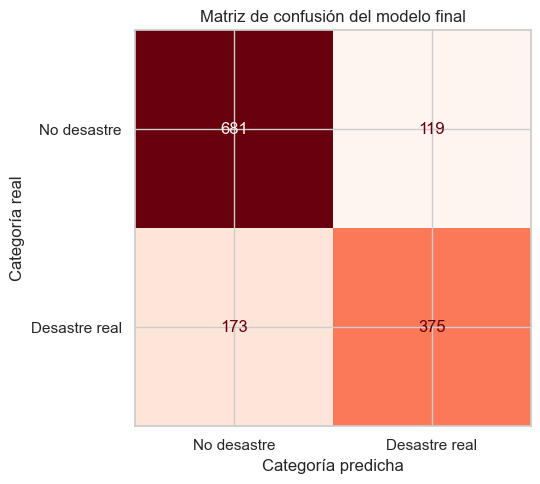

Modelo final: SVM lineal + TF-IDF (1,2) + negatividad


In [30]:
clasificador_final = clasificador_con_negatividad if usar_negatividad else clasificador_mejor_texto
prediccion_final = prediccion_prueba_negatividad if usar_negatividad else prediccion_mejor_texto
nombre_modelo_final = f"{nombre_mejor_modelo} + negatividad" if usar_negatividad else nombre_mejor_modelo

fig, eje = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    target_prueba, prediccion_final,
    display_labels=["No desastre", "Desastre real"],
    cmap="Reds" if usar_negatividad else "Blues", colorbar=False, ax=eje,
)
eje.set_title("Matriz de confusión del modelo final")
eje.set_xlabel("Categoría predicha")
eje.set_ylabel("Categoría real")
plt.tight_layout()
plt.show()
print("Modelo final:", nombre_modelo_final)